# Imports

In [70]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

# Dataset

In [24]:
df = pd.read_json("hf://datasets/Darkester/SimpleLinearRegression/datas.jsonl", lines=True)

# Outliers

=== ДО ОБРАБОТКИ ===
count    5.490000e+02
mean     2.936597e+05
std      9.586300e+05
min     -5.000000e-02
25%      7.300000e+00
50%      1.610000e+01
75%      7.500000e+01
max      5.000000e+06
Name: feature1, dtype: float64

=== ПОСЛЕ ЗАМЕНЫ ВЫБРОСОВ ===
count    474.000000
mean      29.613882
std       37.579928
min       -0.050000
25%        6.700000
50%       14.450000
75%       30.000000
max      175.000000
Name: feature1, dtype: float64
=== ДО ОБРАБОТКИ ===
count    5.490000e+02
mean     3.694217e+05
std      1.195198e+06
min     -1.800000e-01
25%      3.300000e+00
50%      1.550000e+01
75%      4.500000e+01
max      6.000000e+06
Name: feature2, dtype: float64

=== ПОСЛЕ ЗАМЕНЫ ВЫБРОСОВ ===
count    453.000000
mean      17.670397
std       16.633776
min       -0.180000
25%        2.900000
50%       14.100000
75%       27.800000
max       67.000000
Name: feature2, dtype: float64
=== ДО ОБРАБОТКИ ===
count    5.490000e+02
mean     6.252158e+05
std      1.958390e+06
min      4.00

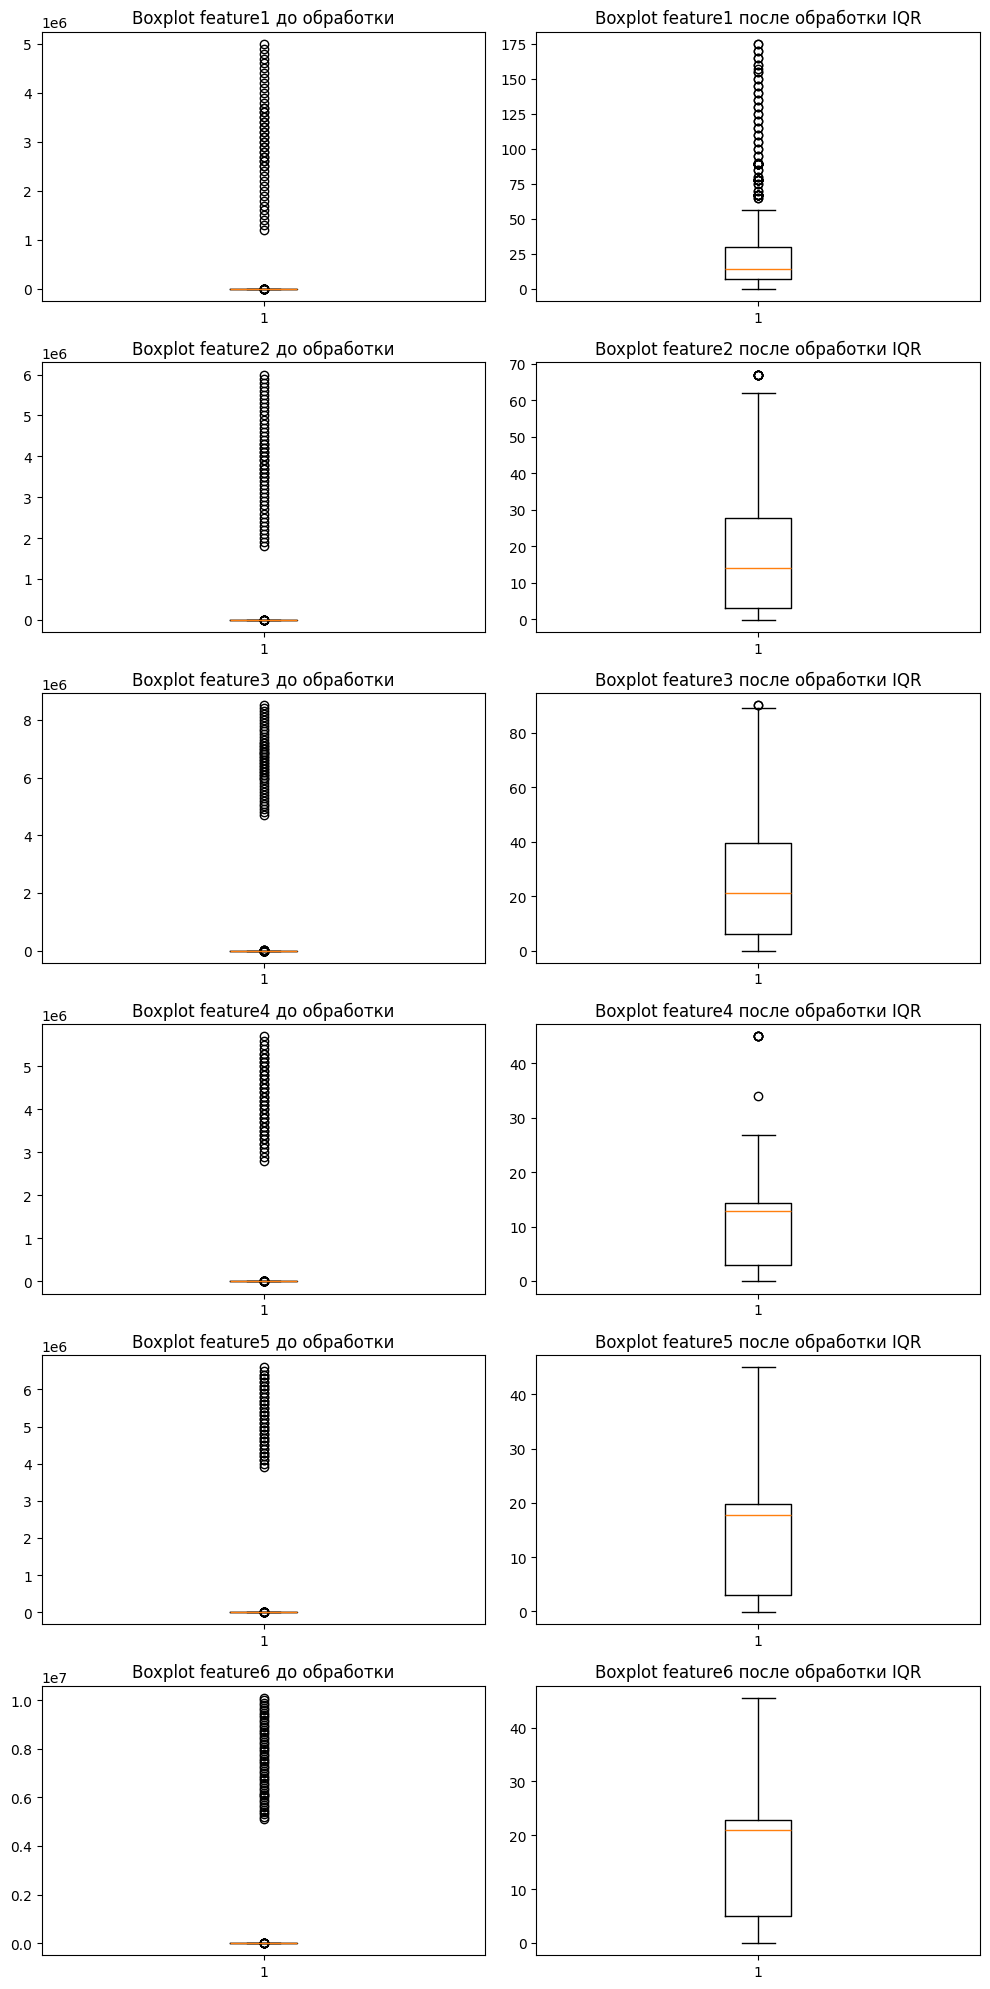

In [62]:
fig, ax = plt.subplots(6, 2, figsize=(10, 20))

df_cleaned = df.copy()

for ind, col in enumerate(df_cleaned.columns.tolist()[:-1]):
    ax[ind][0].boxplot(df[col])
    ax[ind][0].set_title(f'Boxplot {col} до обработки')

    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

    ax[ind][1].boxplot(df_cleaned[col])
    ax[ind][1].set_title(f'Boxplot {col} после обработки IQR')

    print("=== ДО ОБРАБОТКИ ===")
    print(df[col].describe())

    print("\n=== ПОСЛЕ ЗАМЕНЫ ВЫБРОСОВ ===")
    print(df_cleaned[col].describe())

plt.tight_layout()
plt.show()

# Feature Selection

Там в лекции упомянулось по forward/backward elimination, поэтому сделаю их. Так как задача просто отобрать фичи, не делил еще на валид выборку)

In [69]:
Y = df_cleaned['target']
X = df_cleaned.drop(columns='target')

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

In [80]:
selected_fs = []
init_fs = df_cleaned.columns.tolist()[:-1]

total_rmse = np.inf

while len(init_fs) > 0:
    remaining_fs = list(set(init_fs) - set(selected_fs))

    best_rmse = np.inf
    best_f = None

    for f in remaining_fs:
        model = LinearRegression()
        model.fit(X_train[selected_fs + [f]], y_train)

        rmse = root_mean_squared_error(y_test, model.predict(X_test[selected_fs + [f]]))

        if rmse < best_rmse:
            best_f = f
            best_rmse = rmse

    if best_rmse < total_rmse:
        selected_fs.append(best_f)
        total_rmse = best_rmse
    else:
        break

In [83]:
pd.concat([df_cleaned[selected_fs], Y], axis=1)

,feature1,feature3,feature2,feature6,feature5,target
0,5.2,7.8,3.1,6.3,4.0,38.7
1,6.0,8.2,2.8,5.9,3.5,39.1
2,4.8,7.5,3.5,6.1,4.2,37.3
3,5.5,8.0,3.0,6.0,3.8,38.5
4,6.2,7.9,2.9,5.8,3.7,39.3
...,...,...,...,...,...,...
506,67.0,34.0,45.0,3.0,12.0,183.4
511,34.0,67.0,56.0,45.0,12.0,188.7
533,45.0,78.0,67.0,34.0,12.0,193.6
538,67.0,34.0,45.0,3.0,12.0,184.1
